In [1]:
from RRTG_helpers import *
import pandas as pd
import numpy as np
import c_graph_lib.bin.tourny as tou

In [2]:
df = pd.read_csv("../Data/mlb_division_series_results.csv")
df = df.drop(columns=["league", "games_played", "ties", "wins2", "wins1"])
df

,season,division,team1,team2,result
0,1985,AL-East,BAL,BOS,BOS
1,1985,AL-East,BAL,CLE,BAL
2,1985,AL-East,BAL,DET,DET
3,1985,AL-East,BAL,MIL,BAL
4,1985,AL-East,BAL,NYA,NYA
...,...,...,...,...,...
2498,2024,NL-West,COL,SDN,COL
2499,2024,NL-West,COL,SFN,SFN
2500,2024,NL-West,LAN,SDN,SDN
2501,2024,NL-West,LAN,SFN,LAN


In [3]:
div_list = 	["AL-Central", "AL-East", "AL-West", "NL-Central", "NL-East", "NL-West"]

In [4]:
def df_to_tg(df: pd.DataFrame) -> DiGraph:
    
    tg_name: str = f"{df.iloc[int(0)]["division"]} {df.iloc[int(0)]["season"]}"
    edge_list: list[tuple[str, str]] = [
        (row["team1"], row["team2"]) if row["team1"] == row["result"]
        else (row["team2"], row["team1"])
        for (index, row) in df.iterrows()
    ]
    return DiGraph(edge_list,
                   data_structure="static_sparse", 
                   format="list_of_edges", 
                   name=tg_name)

In [5]:
df_year_list = list()
for i in range(1985, 2025):
    for div in div_list:
        tmp_df = df[(df["division"]==div) & (df["season"]==i)]
        if not tmp_df.empty:
            df_year_list.append(tmp_df)

tg_year_list = map(df_to_tg, df_year_list)
test = df_year_list[0]
test

,season,division,team1,team2,result
0,1985,AL-East,BAL,BOS,BOS
1,1985,AL-East,BAL,CLE,BAL
2,1985,AL-East,BAL,DET,DET
3,1985,AL-East,BAL,MIL,BAL
4,1985,AL-East,BAL,NYA,NYA
5,1985,AL-East,BAL,TOR,TOR
6,1985,AL-East,BOS,CLE,BOS
7,1985,AL-East,BOS,DET,DET
8,1985,AL-East,BOS,MIL,MIL
9,1985,AL-East,BOS,NYA,NYA


In [6]:
g = df_to_tg(test)

In [7]:
tourny_dict = {TG : list() for TG in digraphs.tournaments_nauty(5, immutable=True)}
tourny_dict

{Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: []}

In [8]:
for MLB_TG in tg_year_list:
    for g in tourny_dict:
        if MLB_TG.is_isomorphic(g):
            tourny_dict[g].append(MLB_TG)
            break

In [9]:
tourny_stats = [(g, len(tourny_dict[g]), num_upsets(g)) for g in tourny_dict]
tourny_stats

[(Digraph on 5 vertices, 50, 0),
 (Digraph on 5 vertices, 13, 0),
 (Digraph on 5 vertices, 22, 1),
 (Digraph on 5 vertices, 6, 2),
 (Digraph on 5 vertices, 7, 2),
 (Digraph on 5 vertices, 7, 2),
 (Digraph on 5 vertices, 7, 1),
 (Digraph on 5 vertices, 0, 0),
 (Digraph on 5 vertices, 17, 0),
 (Digraph on 5 vertices, 3, 1),
 (Digraph on 5 vertices, 11, 1),
 (Digraph on 5 vertices, 5, 0)]

In [10]:
from sage.repl.ipython_kernel.interact import interact, sage_interactive
@interact
def _(iso_class=sage_interactive.widget_from_iterable(tourny_stats)):
    print("Scoring sequence: ", iso_class[0].out_degree_sequence())
    @interact
    def __(MLB_Graph=sage_interactive.widget_from_iterable(tourny_dict[iso_class[0]])):
        if not MLB_Graph is None:
            upsets, not_upsets = str_upsets_not_upsets(MLB_Graph)
            MLB_Graph.show(
                vertex_size=700,
                edge_colors={'red' : upsets, 'navy' : not_upsets}
            )
        else:
            show(iso_class[0])

Interactive function <function _ at 0x7e7011ed0c20> with 1 widget
  iso_class: Dropdown(description='iso_class', options=((Digraph on 5 vertices, 50, 0), (Digraph on 5 vertices, 13, 0), (Digraph on 5 vertices, 22, 1), (Digraph on 5 vertices, 6, 2), (Digraph on 5 vertices, 7, 2), (Digraph on 5 vertices, 7, 2), (Digraph on 5 vertices, 7, 1), (Digraph on 5 vertices, 0, 0), (Digraph on 5 vertices, 17, 0), (Digraph on 5 vertices, 3, 1), (Digraph on 5 vertices, 11, 1), (Digraph on 5 vertices, 5, 0)), value=(Digraph on 5 vertices, 50, 0))

### Histogram

In [11]:
mlb_upset_list = list()
full_list_upsets = list(tou.upset_generator(int(5), int(0)))

for g, n, u in tourny_stats:
    mlb_upset_list += ([u] * n)

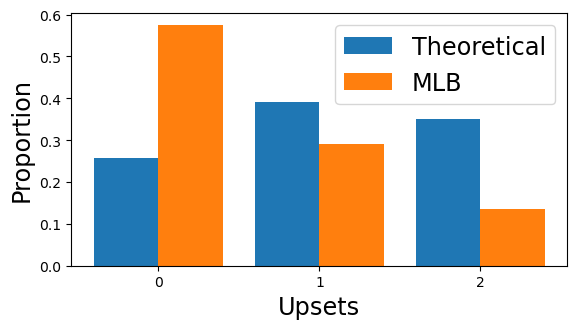

In [12]:
import matplotlib.pyplot as plt

plt.hist([full_list_upsets, mlb_upset_list], bins=[-0.5, 0.5, 1.5, 2.5], density=True, label=['Theoretical', 'MLB'], align="mid", rwidth=0.8)
plt.xticks([0, 1, 2])
plt.ylabel("Proportion", fontsize='xx-large')
plt.xlabel("Upsets", fontsize='xx-large')
plt.legend(loc='upper right', fontsize='xx-large')
plt.savefig("./Comp-MLB.png")
plt.gca().set_aspect(2.6)

Let $X$ be the random variable which uniformly selects from the unquotented sample space of all tournoment graphs of order $5$.

Let $X_{MLB}$ be the random variable with the same sample sapce with probablity based in our MLB data.

Let $\phi(G)$ denote the number of upsets in $G$.

In [13]:
%display latex
show(LatexExpr(f"var\\bigg(\\phi(X_{{MLB}})\\bigg) = {np.var(mlb_upset_list)},\\ \\mathbb E \\bigg(\\phi(X_{{MLB}})\\bigg) = {np.mean(mlb_upset_list)}"))
show(LatexExpr(f"var\\bigg(\\phi(X)\\bigg) = {np.var(full_list_upsets)},\\ \\mathbb E \\bigg(\\phi(X)\\bigg) = {np.mean(full_list_upsets)}"))
%display plain

var\bigg(\phi(X_{MLB})\bigg) = 0.516572315558802,\ \mathbb E \bigg(\phi(X_{MLB})\bigg) = 0.5608108108108109

var\bigg(\phi(X)\bigg) = 0.6005859375,\ \mathbb E \bigg(\phi(X)\bigg) = 1.09375

### Scatter Plot
The following scatter plot has isomorphism classes as points with an $y$-axis correspoinding to the number of occurences in the data and a $x$-axis corresponding to the number of cylces in the representative graph.

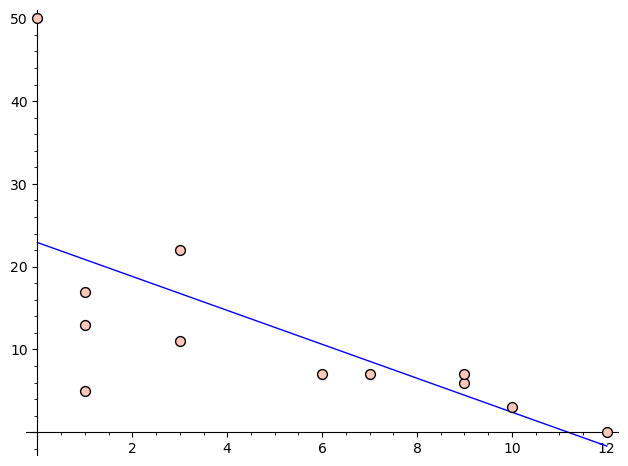

In [14]:
cycles_count_list = [(len(list(g.all_simple_cycles())), len(tourny_dict[g])) for g in tourny_dict]
x_list, y_list = ([p[0] for p in cycles_count_list], [p[1] for p in cycles_count_list])

m, b = np.polyfit(x_list, y_list, deg=1)
m, b

scatter_plot(cycles_count_list, ) + plot(m*x + b, (0,12))

Let $c(G)$ denote the number of cycles in a tournoment $G$

In [15]:
%display latex
show(LatexExpr(f"corr\\bigg(c(X_{{MLB}}),X_{{MLB}}\\bigg) = {np.corrcoef(x_list, y_list)[1][0]}"))
%display plain

corr\bigg(c(X_{MLB}),X_{MLB}\bigg) = -0.6415261846116963

In [16]:
l = list()
for val in tourny_dict.values():
    l += list(filter(lambda g : g.name() == "NL-Central 2024", val))
l
g = l[0]

In [17]:
from graph_plot_js import tourny_html_code
from sage.misc.viewer import browser

os.system('%s %s 2>/dev/null 1>/dev/null &' % (browser(), tourny_html_code(G=g, vertex_labels=True, edge_partition=str_upsets_not_upsets(g), link_distance=300, vertex_size=9, edge_thickness=6)))

0

In [18]:
order = int(5)
iso_class_size_dict = {TG : 0 for TG in digraphs.tournaments_nauty(order, immutable=True)}
for g in tou.unnamed_TG(order):
    for iso_class in iso_class_size_dict:
        if iso_class.is_isomorphic(DiGraph(g.to_tuple(), immutable=True, format='list_of_edges')):
            iso_class_size_dict[iso_class] += 1
            continue
            
iso_class_size_dict

{Digraph on 5 vertices: 120,
 Digraph on 5 vertices: 40,
 Digraph on 5 vertices: 120,
 Digraph on 5 vertices: 120,
 Digraph on 5 vertices: 120,
 Digraph on 5 vertices: 120,
 Digraph on 5 vertices: 120,
 Digraph on 5 vertices: 24,
 Digraph on 5 vertices: 40,
 Digraph on 5 vertices: 40,
 Digraph on 5 vertices: 120,
 Digraph on 5 vertices: 40}

In [19]:
score_seq_freq_dict = {tuple(g.out_degree_sequence()) : 0 for g in iso_class_size_dict.keys()}
for iso_class in iso_class_size_dict:
     score_seq_freq_dict[tuple( iso_class.out_degree_sequence() )] += iso_class_size_dict[iso_class]

score_seq_freq_dict

{(4, 3, 2, 1, 0): 120,
 (3, 3, 3, 1, 0): 40,
 (4, 2, 2, 1, 1): 120,
 (3, 2, 2, 2, 1): 280,
 (3, 3, 2, 1, 1): 240,
 (2, 2, 2, 2, 2): 24,
 (4, 2, 2, 2, 0): 40,
 (3, 3, 2, 2, 0): 120,
 (4, 3, 1, 1, 1): 40}

In [20]:
mlb_score_seq_freq_dict = {tuple(g.out_degree_sequence()) : 0 for g,n,u in tourny_stats}
for g,n,u in tourny_stats:
     mlb_score_seq_freq_dict[tuple( g.out_degree_sequence() )] += n

mlb_score_seq_freq_dict

{(4, 3, 2, 1, 0): 50,
 (3, 3, 3, 1, 0): 13,
 (4, 2, 2, 1, 1): 22,
 (3, 2, 2, 2, 1): 16,
 (3, 3, 2, 1, 1): 14,
 (2, 2, 2, 2, 2): 0,
 (4, 2, 2, 2, 0): 17,
 (3, 3, 2, 2, 0): 11,
 (4, 3, 1, 1, 1): 5}

In [21]:
score_seq_prop_arr = np.array(list(score_seq_freq_dict.values()), dtype=np.float64) * (1 / sum(score_seq_freq_dict.values()))
mlb_score_seq_prop_arr = np.array(list(mlb_score_seq_freq_dict.values()), dtype=np.float64) * (1 / sum(mlb_score_seq_freq_dict.values()))
score_seq_prop_arr, mlb_score_seq_prop_arr

(array([0.1171875, 0.0390625, 0.1171875, 0.2734375, 0.234375 , 0.0234375,
        0.0390625, 0.1171875, 0.0390625]),
 array([0.33783784, 0.08783784, 0.14864865, 0.10810811, 0.09459459,
        0.        , 0.11486486, 0.07432432, 0.03378378]))

Text(0.5, 0, 'Sequences')

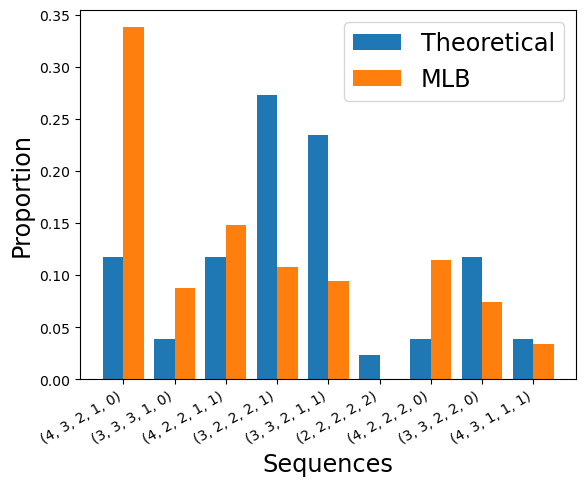

In [22]:
x = np.arange(len(mlb_score_seq_prop_arr))

plt.bar(x-float(0.2), score_seq_prop_arr, 0.40)
plt.bar(x+float(0.2), mlb_score_seq_prop_arr, 0.40)
plt.xticks(x, score_seq_freq_dict.keys(), rotation=30, ha='right')

plt.legend(['Theoretical', 'MLB'], loc='upper right', fontsize='xx-large')
plt.ylabel("Proportion", fontsize='xx-large')
plt.xlabel("Sequences", fontsize='xx-large')